In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/tabular/heart_uci.csv')
print(df.shape)
df.head()



(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing: 0


C:\Users\Balaji\AppData\Local\Temp\ipykernel_22072\1948421012.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=['#4CAF50','#F44336'])


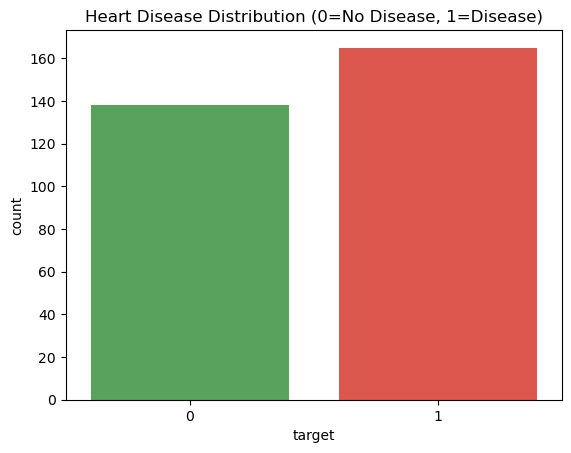

target
1    165
0    138
Name: count, dtype: int64
target
1    54.5
0    45.5
Name: proportion, dtype: float64


In [5]:
import os
os.makedirs('../reports', exist_ok=True)

sns.countplot(x='target', data=df, palette=['#4CAF50','#F44336'])
plt.title('Heart Disease Distribution (0=No Disease, 1=Disease)')
plt.savefig('../reports/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).mul(100).round(1))


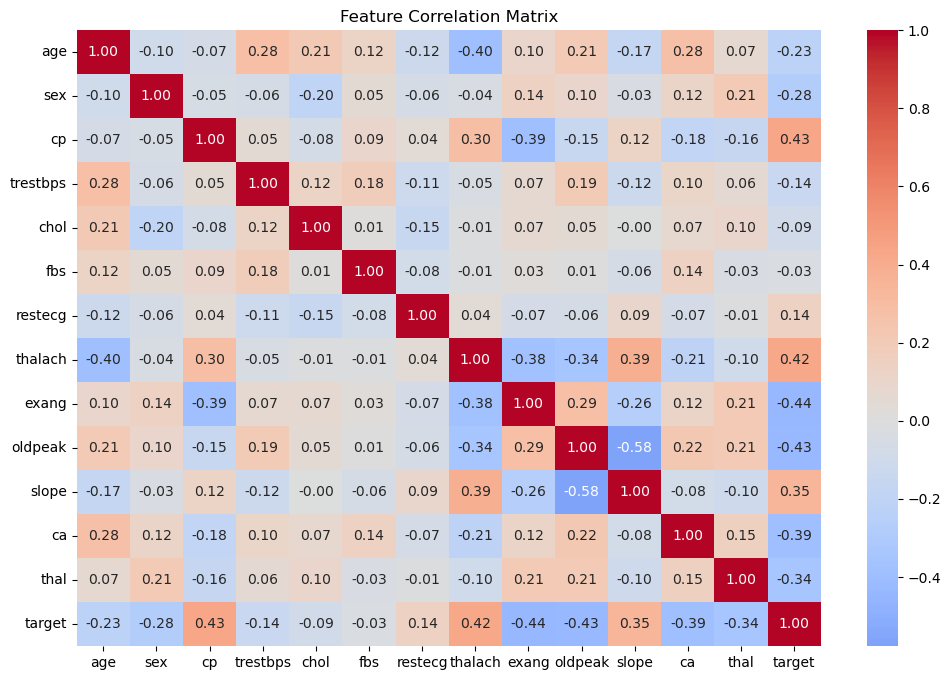

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.savefig('../reports/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

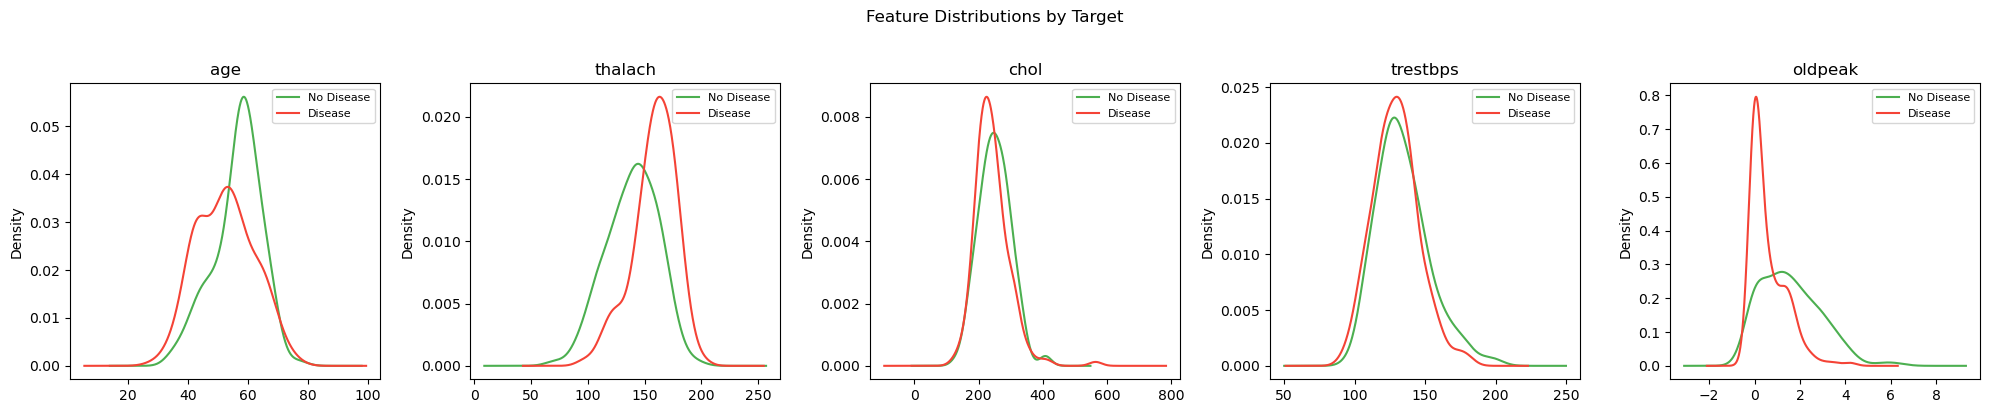

In [7]:
features = ['age', 'thalach', 'chol', 'trestbps', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, feat in zip(axes, features):
    for val, label, color in [(0,'No Disease','#4CAF50'),(1,'Disease','#F44336')]:
        df[df['target']==val][feat].plot(kind='kde', ax=ax, label=label, color=color)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Target', y=1.02)
plt.tight_layout()
plt.savefig('../reports/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print("=" * 40)
print("       DATASET SUMMARY")
print("=" * 40)
print(f"Total patients  : {len(df)}")
print(f"Features        : {df.shape[1]-1}")
print(f"Disease cases   : {df['target'].sum()} ({df['target'].mean()*100:.1f}%)")
print(f"Healthy cases   : {(df['target']==0).sum()} ({(df['target']==0).mean()*100:.1f}%)")
print(f"Missing values  : {df.isnull().sum().sum()}")
print("=" * 40)
print("\nFeature data types:")
print(df.dtypes)

       DATASET SUMMARY
Total patients  : 303
Features        : 13
Disease cases   : 165 (54.5%)
Healthy cases   : 138 (45.5%)
Missing values  : 0

Feature data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object
